# **Main Drivers of Late Deliveries:**

> **`What to do`?:** 
>   
> **Identify the main drivers of late deliveries** to reduce the number of shipments that don't arrive on time. 

In [244]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [245]:
import warnings 
warnings.filterwarnings("ignore")

In [246]:
# Import data for analysis: 
data= pd.read_json("data.json")

In [247]:
data.shape

(10999, 12)

In [248]:
data.sample(3)

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
5449,5450,F,Ship,5,3,169,4,low,F,4,5683,0
10535,10536,F,Road,4,1,211,3,medium,F,7,4083,1
8769,8770,B,Flight,5,2,174,5,medium,M,8,4656,0


## **1. Overall On-Time Delivery Rate:**  

Here, we want to calculate the overall on-time delivery rate for all the deliveries:

In [249]:
data.head()

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [250]:
the_ratio= data["reached_on_time"].value_counts(normalize= True).reset_index()
the_ratio

,reached_on_time,proportion
0,1,0.596691
1,0,0.403309


In [251]:
the_ratio.columns = ["status", "proportion"]  # Rename columns for clarity
the_ratio

,status,proportion
0,1,0.596691
1,0,0.403309


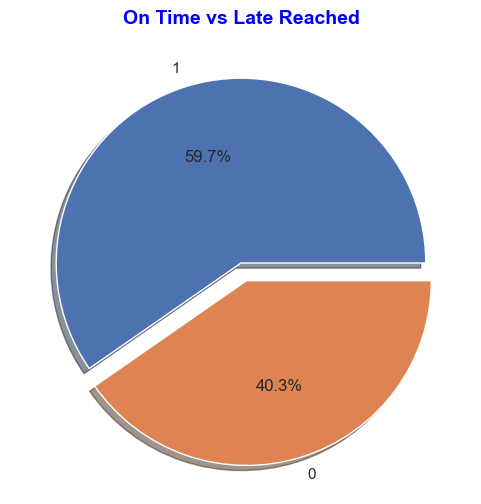

In [252]:
plt.figure(figsize=(6,6))
plt.pie(
    x=the_ratio["proportion"],
    explode=[0, 0.1],
    labels=the_ratio["status"],  # Use actual labels from data
    shadow=True,
    autopct='%1.1f%%'
)
plt.title("On Time vs Late Reached", fontsize=14, fontweight="bold", loc="center", color="blue")
plt.show()

In [253]:
the_ratio= data["reached_on_time"].value_counts()

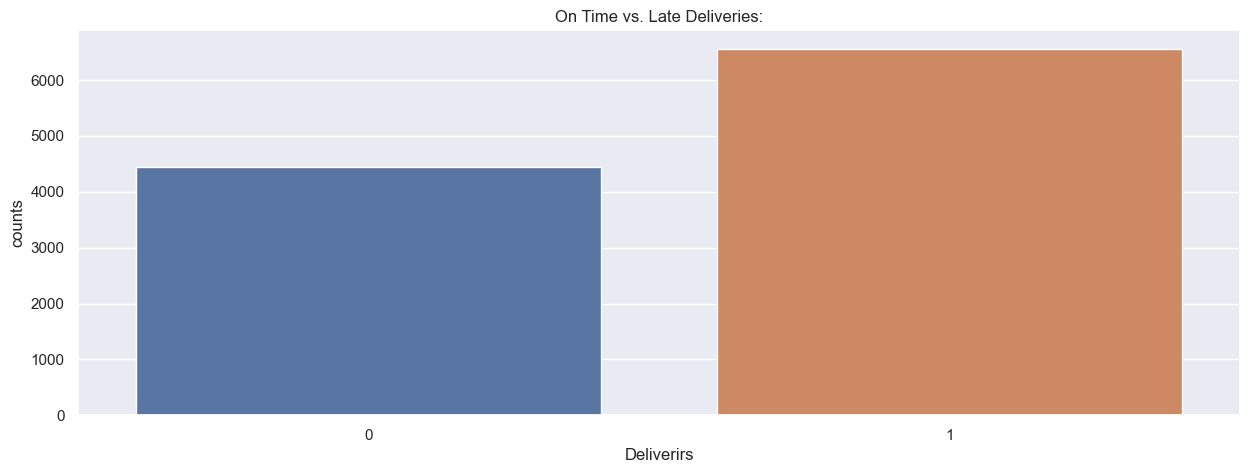

In [254]:
plt.figure(figsize=(15, 5))
sns.set_theme(context="notebook", style="darkgrid", palette="deep")
the_ratio = data["reached_on_time"].value_counts().reset_index()
the_ratio.columns = ["reached_on_time", "count"]
sns.barplot(x="reached_on_time", y="count", data=the_ratio, palette="deep", 
            hue= "reached_on_time", legend= False)
plt.title("On Time vs. Late Deliveries:")
plt.xlabel("Deliverirs")
plt.ylabel("counts")
plt.show()

So, overall, 40% of the deliveries are not reaching to the customers doors at time. This is obviously a big margin and we try to analyze the issues and give appropriate solutions.

---

## **2. Delay Rate by Warehouse Block:**

In [255]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [256]:
blob= data.groupby("warehouse_block")["reached_on_time"].value_counts(normalize= True).reset_index()
blob

,warehouse_block,reached_on_time,proportion
0,A,1,0.586470
1,A,0,0.413530
2,B,1,0.602291
3,B,0,0.397709
4,C,1,0.596836
5,C,0,0.403164
6,D,1,0.597601
7,D,0,0.402399
8,F,1,0.598472
9,F,0,0.401528


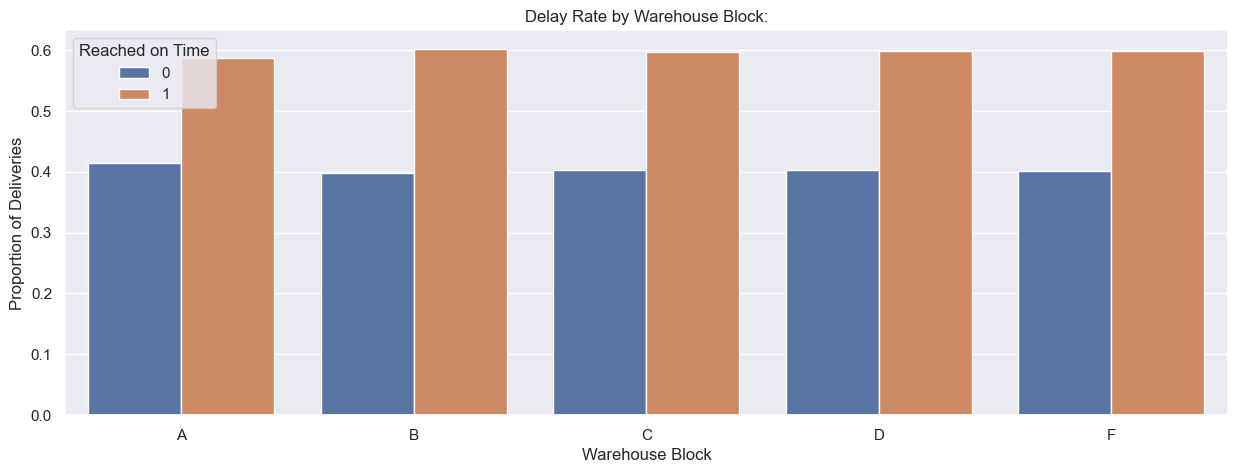

In [257]:
plt.figure(figsize=(15, 5))
sns.set_theme(context="notebook", style="darkgrid", palette="deep")
sns.barplot(data= blob, x="warehouse_block", y="proportion", hue="reached_on_time", palette="deep")
plt.title("Delay Rate by Warehouse Block:")
plt.xlabel("Warehouse Block")
plt.ylabel("Proportion of Deliveries")
plt.legend(title="Reached on Time", loc= "upper left")
plt.show()

All the warehouses on average perform identically and we can say that non of the warehouse is contributing significantly high on the delay of shipments.

<Axes: xlabel='warehouse_block', ylabel='count'>

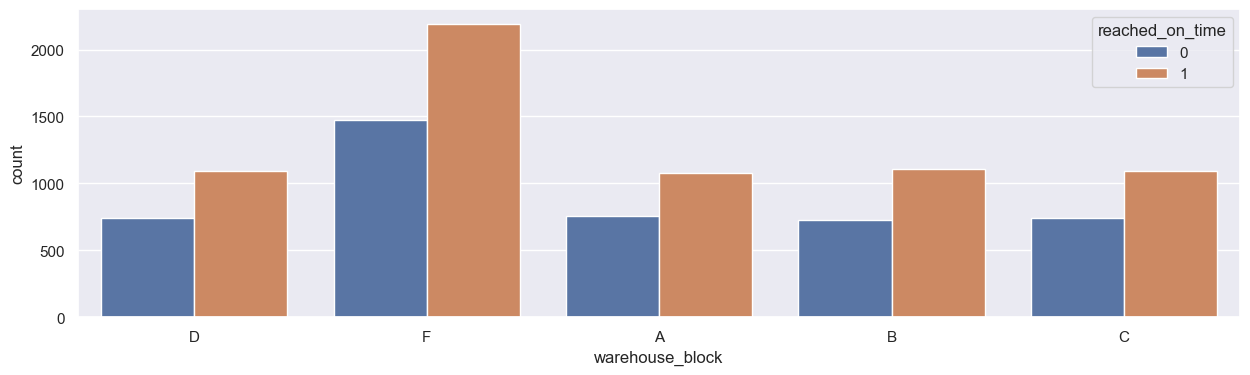

In [258]:
plt.figure(figsize= (15,4))
sns.countplot(data= data, x= "warehouse_block", hue= "reached_on_time", palette= "deep")

This is non-normalized (not expressed in percentage terms) plot which at first glance may shows warehouse `F` may be contributing high on the overall delivery performance but it is based on the overall raw delivery counts and do not represent the overall performance rate of the warehouse. Warehouse `F` have shipped almost double of what each of the other warehouses shipped but it's the overall ontime delivery is almost identical with other warehouses. 

----

## **3. Delay Rate by Mode of Shipment:**

Which shipping methods (`Ship`, `Flight`, `Road`) are most and least reliable in terms of on-time delivery?

In [259]:
a= data.groupby("mode_of_shipment")["reached_on_time"].value_counts(normalize= True).reset_index()
a

,mode_of_shipment,reached_on_time,proportion
0,Flight,1,0.601576
1,Flight,0,0.398424
2,Road,1,0.588068
3,Road,0,0.411932
4,Ship,1,0.597561
5,Ship,0,0.402439


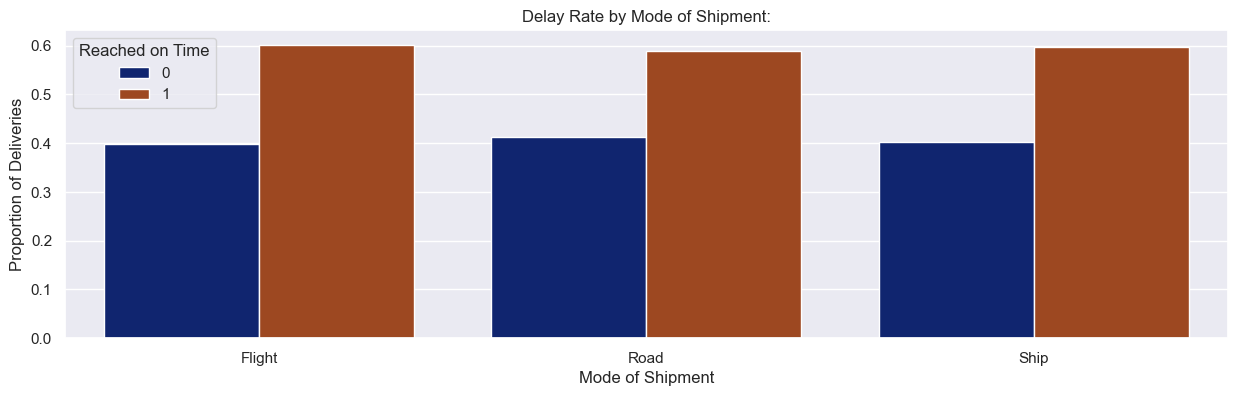

In [260]:
plt.figure(figsize= (15, 4))
sns.set_theme(context= "notebook", style= "darkgrid", palette= "dark")
sns.barplot(data= a, x= "mode_of_shipment", y= "proportion", hue= "reached_on_time")
plt.title("Delay Rate by Mode of Shipment:")
plt.xlabel("Mode of Shipment")
plt.ylabel("Proportion of Deliveries")
plt.legend(title="Reached on Time", loc= "upper left")
plt.show()

There is not much difference on the on-time delivery of products according to their mode of shipment. There are very subtle differences: Each mode of shipment have about 60% (plus/minus) 2% on-time delivery success rate.

In [261]:
data.groupby("mode_of_shipment")["reached_on_time"].mean().reset_index()

,mode_of_shipment,reached_on_time
0,Flight,0.601576
1,Road,0.588068
2,Ship,0.597561


This again signals to same thing that, about 60% deliveries will be on time irrespective of the mode of shipments: `flight`, `road` and `ship`.

In [262]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

<Axes: xlabel='mode_of_shipment', ylabel='count'>

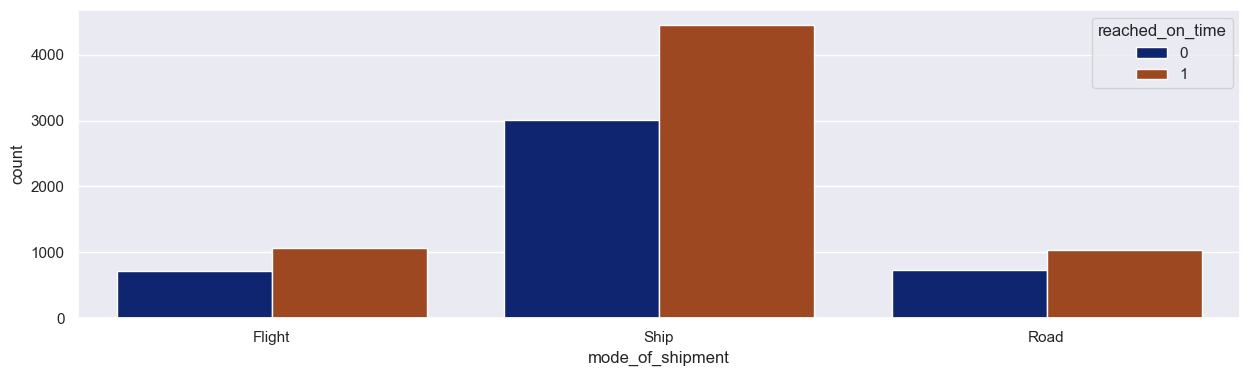

In [263]:
plt.figure(figsize= (15, 4))
sns.set_theme(context= "notebook", style= "darkgrid", palette= "deep")
sns.countplot(data= data, x= "mode_of_shipment", hue= "reached_on_time", palette= "dark")

## **4. Impact of Product Importance on Delays:**

In [264]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [265]:
data["product_importance"].value_counts()

product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64

In [266]:
b= data.groupby(by= "product_importance")["reached_on_time"].value_counts(normalize= True).reset_index()
b

,product_importance,reached_on_time,proportion
0,high,1,0.649789
1,high,0,0.350211
2,low,1,0.592788
3,low,0,0.407212
4,medium,1,0.590450
5,medium,0,0.409550


In [267]:
data.groupby("product_importance")["reached_on_time"].mean()

product_importance
high      0.649789
low       0.592788
medium    0.590450
Name: reached_on_time, dtype: float64

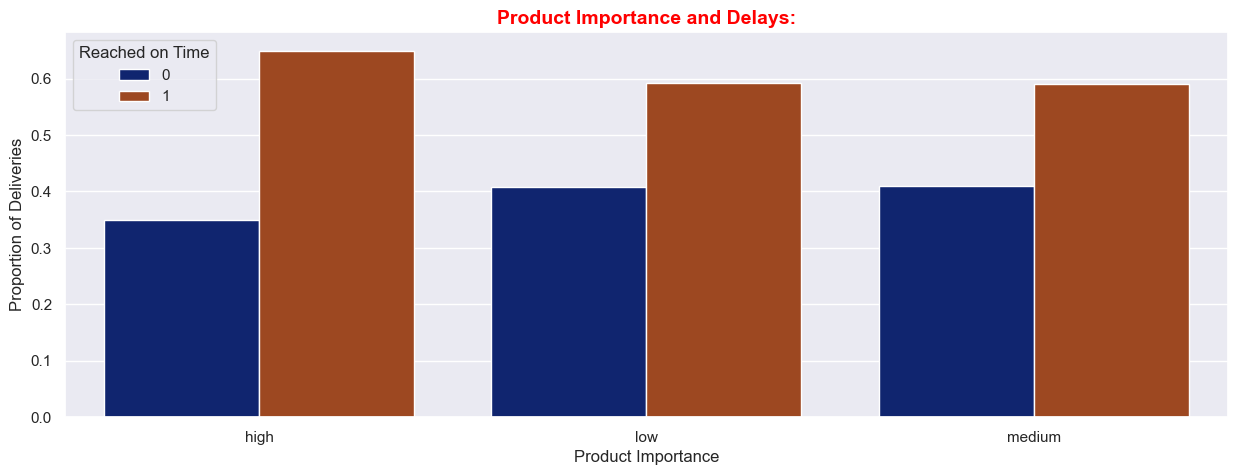

In [268]:
plt.figure(figsize=(15, 5))
sns.set_theme(context="notebook", style="darkgrid", palette="deep")
sns.barplot(data= b, x= "product_importance", y= "proportion", hue= "reached_on_time", palette= "dark")
plt.title("Product Importance and Delays:", fontsize= 14, fontweight= "bold", loc= "center", color= "red")
plt.xlabel("Product Importance")
plt.ylabel("Proportion of Deliveries")
plt.legend(title="Reached on Time", loc= "upper left")
plt.show()

This analysis shows that the high importance products do have some proprity in the shipment of the products. 

----
----

## **5. Correlation between Weight and Delays:**

If heavier shipments are more prone to delays?

In [269]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [270]:
data[["weight_gms", "reached_on_time"]].head()

,weight_gms,reached_on_time
0,1233,1
1,3088,1
2,3374,1
3,1177,1
4,2484,1


In [271]:
data[["weight_gms", "reached_on_time"]].corr(method= "spearman")

,weight_gms,reached_on_time
weight_gms,1.000000,-0.265958
reached_on_time,-0.265958,1.000000


So, the correlation coefficient for `weight_gms` and `reached_on_time` is `-0.265958`. This is a low negative correlation and indicates that as the weight of the product increases the probability of on-time delivery of that product tends to decrease (weakly) and in a linear fashion. 

Also, 

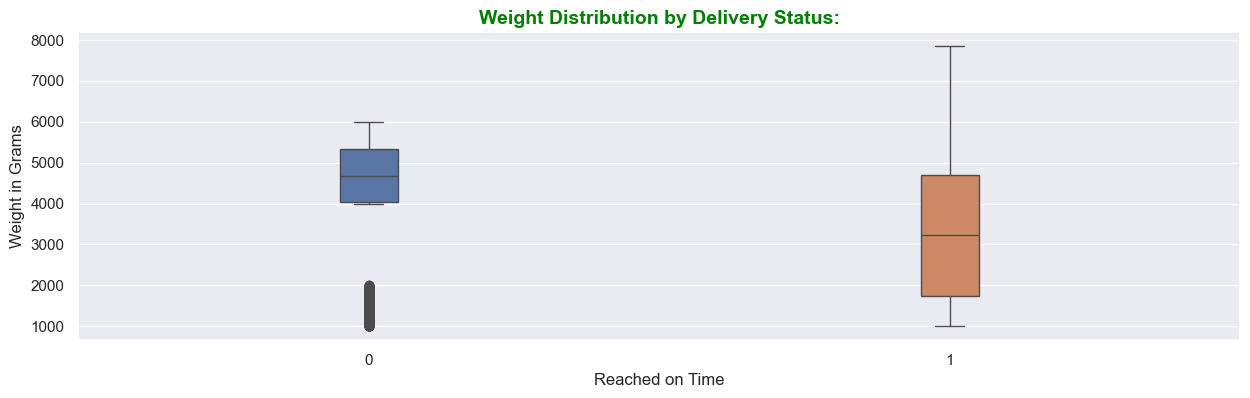

In [272]:
plt.figure(figsize=(15, 4))
sns.set_theme(context="notebook", style="darkgrid", palette="deep")
sns.boxplot(data= data, x= "reached_on_time", y="weight_gms", palette="deep", width=0.1)
plt.title("Weight Distribution by Delivery Status:", fontsize= 14, fontweight= "bold", loc= "center", color= "green")
plt.xlabel("Reached on Time")
plt.ylabel("Weight in Grams")
plt.show()

Packages that were not delivered on time tend to have heavier, more consistent weights (except for a few `very light outliers`). On-time deliveries show more variation and typically lighter median weight. In generally, heavier packages are more likely to be delayed.

----
----

## **6. Impact of Discounts on Delivery Time:**

In [273]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

The `discount_offered` term is a percentage term. We can get the mean percentage discount for each category: `reached_on_time` and `delayed_delivery` in the following ways:

In [274]:
sad= data.groupby(by= "reached_on_time")["discount_offered"].mean().reset_index()
sad

,reached_on_time,discount_offered
0,0,5.545987
1,1,18.663721


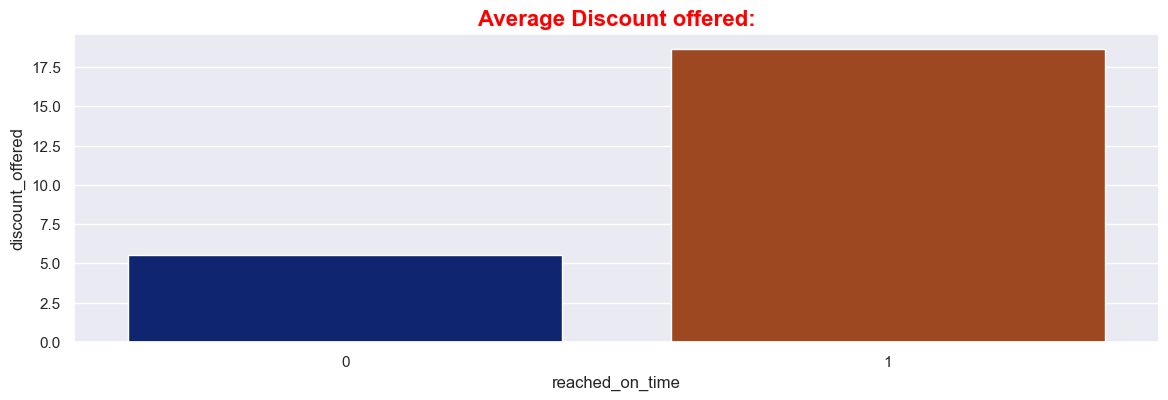

In [275]:
plt.figure(figsize= (14, 4))
sns.barplot(data= sad, x= "reached_on_time", y= "discount_offered", palette= "dark", hue= "discount_offered", legend= False)
plt.title("Average Discount offered:", fontsize= 16, fontweight= "bold", color= "red", loc= "center")
plt.show()

So, on average, there is low discount given for `late_delivery` products. Products what were delivered on time were also give comparatively high discounts (nearly 4 times). 

**Correlation between discount and on-time-delivery:**

In [276]:
# Finding the correlation for on-time delivery and discount offered: 
corr_discount = data[["reached_on_time", "discount_offered"]].corr(method="spearman")
corr_discount

,reached_on_time,discount_offered
reached_on_time,1.000000,0.335108
discount_offered,0.335108,1.000000


This also shows the same thing: products which were delivered on time also have higher discount offered. But, one thing we need to make note here is that, we are considering `reached_on_time` as a continuous variable but infact it is a categorical variable. So, the results it shows may not represent the true nature of their relationship. To make sure, lets plot the relationship between `delivery_on_time` and the discoun`t_offered to the products.

<Axes: xlabel='reached_on_time', ylabel='discount_offered'>

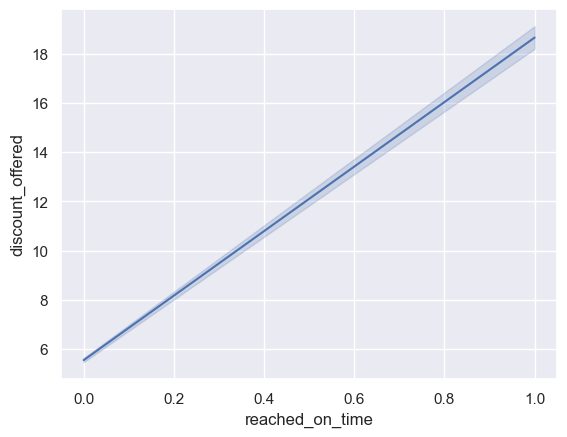

In [277]:
sns.lineplot(data= data, x= "reached_on_time", y= "discount_offered")

<Axes: xlabel='reached_on_time', ylabel='discount_offered'>

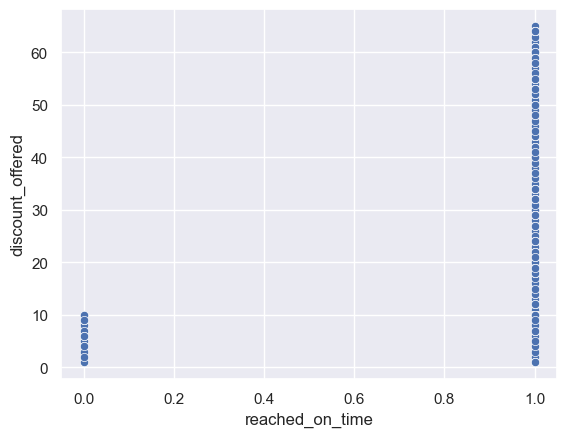

In [278]:
sns.scatterplot(data= data, x= "reached_on_time", y= "discount_offered")

This confirms to same conclusion: There is unusual relation between the `on_time_delivery` and the discount offered. Products that delivered on time are generally getting more discounts whereas products having late deliveries tends to have less discounts offered.

----
---

## **7. Customer Care Calls as a Predictor of Delays:**

In [279]:
data.head()

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [280]:
data6= data[["customer_care_calls", "reached_on_time"]]
data6.head()

,customer_care_calls,reached_on_time
0,4,1
1,4,1
2,2,1
3,3,1
4,2,1


In [281]:
data.groupby(by= "reached_on_time")["customer_care_calls"].mean()

reached_on_time
0    4.147656
1    3.991467
Name: customer_care_calls, dtype: float64

<Axes: xlabel='reached_on_time'>

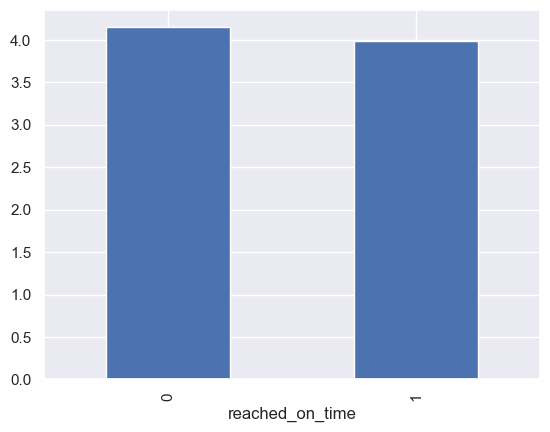

In [282]:
data.groupby(by= "reached_on_time")["customer_care_calls"].mean().plot(kind= "bar")

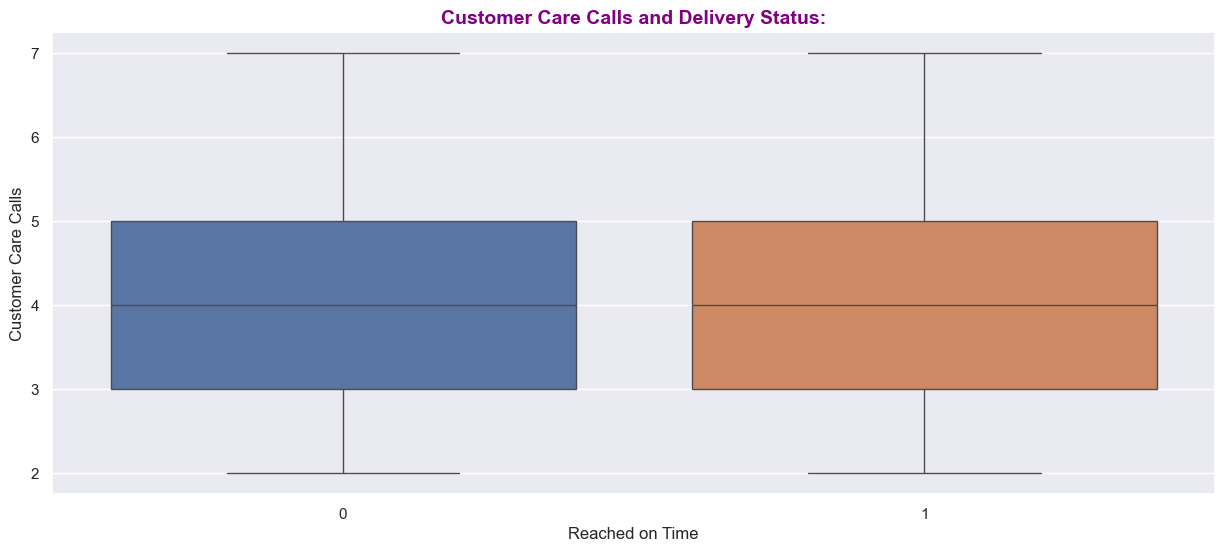

In [283]:
plt.figure(figsize=(15, 6))
sns.set_theme(context="notebook", style="darkgrid", palette="deep")
sns.boxplot(data=data6, x="reached_on_time", y="customer_care_calls", palette="deep")
plt.title("Customer Care Calls and Delivery Status:", fontsize= 14, fontweight= "bold", loc= "center", color= "purple")
plt.xlabel("Reached on Time")
plt.ylabel("Customer Care Calls")
plt.show()

This suggests that the number of customer care calls alone do not seem to have a direct impact on product deliverys and we must consider other factors to get more conclusive evidence.

-----
-----

## **8. Cost of Product vs. Delivery Performance:**

In [284]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [285]:
data.head()

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [286]:
data.groupby(by= "reached_on_time")["cost_of_product"].mean().reset_index()

,reached_on_time,cost_of_product
0,0,214.498647
1,1,207.289197


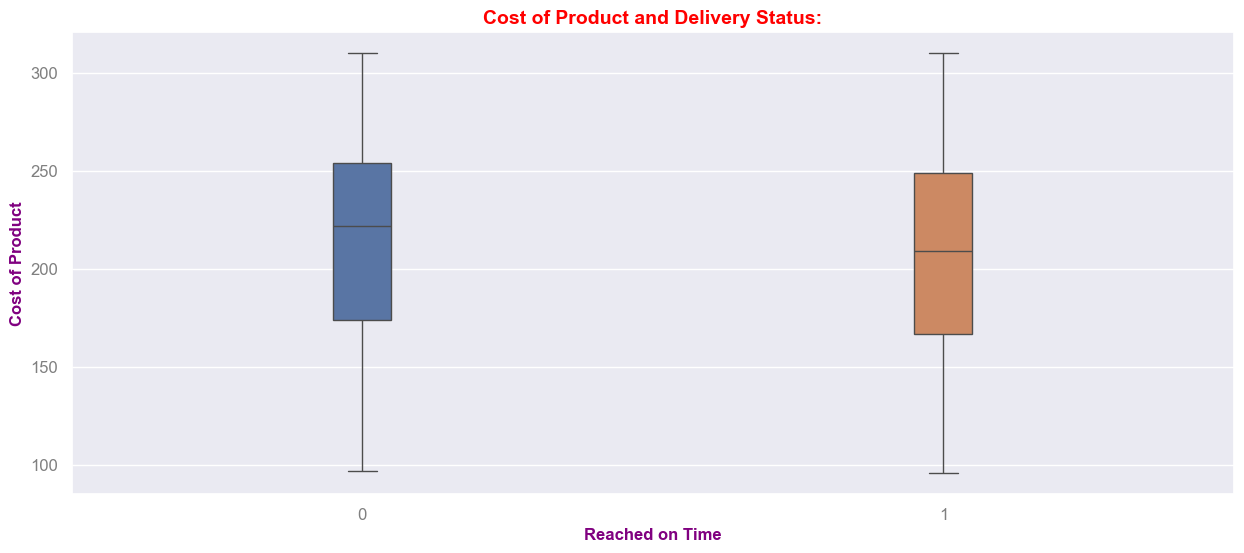

In [287]:
plt.figure(figsize=(15, 6))
sns.set_theme(context="notebook", style="darkgrid", palette="deep")
sns.boxplot(data=data, x="reached_on_time", y="cost_of_product", palette="deep", width=0.1)
plt.title("Cost of Product and Delivery Status:", fontsize= 14, fontweight= "bold", loc= "center", color= "Red")
plt.xlabel("Reached on Time", fontsize= 12, fontweight= "bold", color= "purple", loc= "center")
plt.ylabel("Cost of Product", fontsize= 12, fontweight= "bold", color= "purple", loc= "center")
plt.xticks(color= "gray", rotation= 0, fontsize= 12)
plt.yticks(color= "gray", rotation= 0, fontsize= 12)
plt.show()

So, this is the relation, on average, products which are not delivered on time have higher mean price comparative to products delivering on time. That is, high price products are delivering late comparative to low price. More expensive products should have better performance on delivery but data shows opposite.

---
---

## **9. Gender and Delivery Delays:**

In [288]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [289]:
data9= data[["gender", "reached_on_time"]]
data9.head(4)

,gender,reached_on_time
0,F,1
1,M,1
2,M,1
3,M,1


In [290]:
data9["gender"].unique()

array(['F', 'M'], dtype=object)

In [291]:
xx= data.groupby(by= "gender")["reached_on_time"].value_counts(normalize=True).reset_index()  
xx

,gender,reached_on_time,proportion
0,F,1,0.594409
1,F,0,0.405591
2,M,1,0.599010
3,M,0,0.400990


<Axes: xlabel='reached_on_time', ylabel='proportion'>

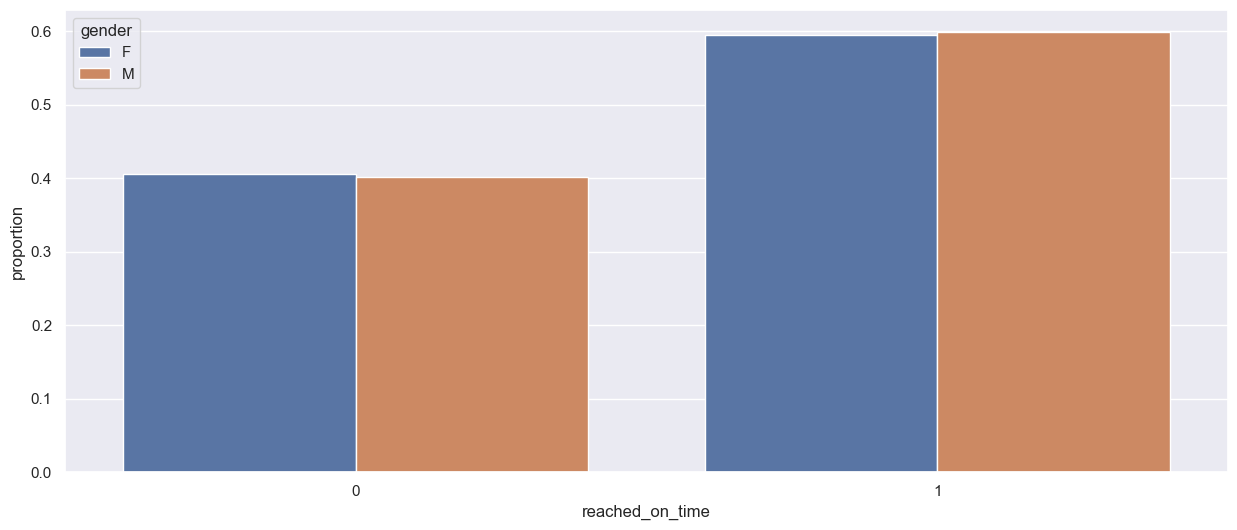

In [292]:
plt.figure(figsize=(15, 6))
sns.set_theme(context="notebook", style="darkgrid", palette="deep")
sns.barplot(data= xx, hue= "gender", y= "proportion", x= "reached_on_time", palette="deep")

So, product reaching on time is not dependent on whether it was ordered from a male or a female customer. This shows there is no bias or difference in delivery performance based on the customer's gender.

----
----

## **10. Predictive Model for Delays:**

* **Description:** Build a machine learning model to predict whether a shipment will be late based on its characteristics. This identifies the most influential factors.

* **How to do it in Python:** Use the Scikit-learn library. Separate your data into features (all columns except ID and the target) and the target (`Reached.on.Time_Y.N`). Encode categorical variables. Train a classification model like `LogisticRegression` or `RandomForestClassifier`. After training, you can inspect the model's `feature_importances_` to see which factors have the biggest impact on predicting delays.

**`Pipeline()`:**
   * `Pipeline` chains together a sequence of steps (transformers and a final estimator).
   * Ensures that the same data flow (fit/transform) is applied during training and inference.

```python
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),    # transformer
    ('model', LogisticRegression())  # estimator (last step must be estimator)
])
```

#### Usage:

```python
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)
```

**`make_pipeline()`:**

* A **convenience function** to create a `Pipeline` **without naming the steps manually**.
* Names are automatically generated from class names in lowercase.

```python
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(StandardScaler(), LogisticRegression())
```

This is **functionally identical** to:

```python
Pipeline([
    ('standardscaler', StandardScaler()),
    ('logisticregression', LogisticRegression())
])
```


**`ColumnTransformer()`:**


* Applies **different preprocessing steps to different columns**.
* Very useful when working with mixed data types (e.g., numeric + categorical).

```python
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(), categorical_features)
])
```

```python
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

full_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression())
])

full_pipeline.fit(X_train, y_train)
predictions = full_pipeline.predict(X_test)
```

---

### Summary Table

| Function              | Purpose                                      | When to Use                   |
| --------------------- | -------------------------------------------- | ----------------------------- |
| `Pipeline()`          | Chain named steps (transformers → estimator) | Full control over step names  |
| `make_pipeline()`     | Quick pipeline creation (auto-named steps)   | Fast prototyping              |
| `ColumnTransformer()` | Different transforms for different columns   | Mixed-type data preprocessing |

---

### Example with All Three Together:

```python
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

# Sample Data
df = pd.DataFrame({
    'age': [25, 32, 47],
    'income': [50000, 64000, 120000],
    'gender': ['M', 'F', 'F'],
    'purchased': [0, 1, 1]
})

X = df[['age', 'income', 'gender']]
y = df['purchased']

# Feature groups
num_cols = ['age', 'income']
cat_cols = ['gender']

# Column-wise transformer
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(), cat_cols)
])

# Final pipeline
clf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier())
])

clf_pipeline.fit(X, y)
print(clf_pipeline.predict(X))
```

---

Let me know if you want code for cross-validation or model comparison using pipelines.
